<a href="https://colab.research.google.com/github/fzkmdly/Strait_Hormuz_act/blob/main/Clustering_Hormuz_crisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Tujuan Awal (Business Objective) adalah: Melakukan Segmentasi Risiko Kapal (Vessel Risk Profiling).**

In [ ]:
!pip install psycopg2-binary sqlalchemy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 19.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import psycopg2
from sqlalchemy import create_engine
import unittest
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("moaz1911/strait-of-hormuz-2026-the-great-decoupling")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'strait-of-hormuz-2026-the-great-decoupling' dataset.
Path to dataset files: /kaggle/input/strait-of-hormuz-2026-the-great-decoupling


In [ ]:
df = pd.read_csv('/kaggle/input/strait-of-hormuz-2026-the-great-decoupling/hormuz_trade_tier_continental_2026.csv')

df

,date,vessel_name,mmsi,flag,trade_tier,transit_status,toll_usd,rerouted,commodity,destination,...,insurance_cost_usd,days_delayed,extra_fuel_tonnes,reroute_penalty_usd,total_transit_cost_usd,naval_escort_status,estimated_cargo_value_usd,total_asset_value_at_risk_usd,continent,inflation_premium_per_unit
0,2026-03-01,MarchVessel_1,100000001,India,Privileged,Passed,0,No,Various,Global Port,...,40000,0,0,0,40000,Light (Cooperative),80000000,160000000,Asia,NaN
1,2026-03-01,MarchVessel_2,100000002,Iran,Privileged,Passed,0,No,Crude Oil,Hidden,...,70000,0,0,0,70000,Internal (IRGC Navy),240000000,380000000,Asia,0.035000
2,2026-03-01,MarchVessel_3,100000003,Iran,Privileged,Passed,0,No,Crude Oil,Hidden,...,70000,0,0,0,70000,Internal (IRGC Navy),240000000,380000000,Asia,0.035000
3,2026-03-02,MarchVessel_4,100000004,Greece,Taxed,Passed,2000000,No,Various,Global Port,...,1000000,0,0,0,3000000,NaN,80000000,160000000,Europe,NaN
4,2026-03-02,MarchVessel_5,100000005,Iran,Privileged,Passed,0,No,Crude Oil,Hidden,...,70000,0,0,0,70000,Internal (IRGC Navy),240000000,380000000,Asia,0.035000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1885,2026-05-31,Iron Carrier 15,386403601,UK,Blocked,Rerouted,0,Yes (Cape of Good Hope),Bulk Carrier,Mumbai,...,67500,12,480,607200,674700,NaN,50000000,95000000,Europe,NaN
1886,2026-05-31,Global Star 34,369408512,Iran,Privileged,Passed,0,No,Container Ship,Hidden/Private,...,55000,0,0,0,55000,Internal (IRGC Navy),150000000,260000000,Asia,3.666667
1887,2026-05-31,Red Spirit 36,559556395,Liberia,Taxed,Passed,2000000,No,LNG Carrier,Houston,...,2750000,0,0,0,4750000,NaN,200000000,420000000,Africa,1.397059
1888,2026-05-31,Eastern Titan 10,238114122,Russia,Privileged,Passed,0,No,Container Ship,Hidden/Private,...,55000,0,0,0,55000,Heavy (PLAN/RF Navy),150000000,260000000,Eurasia,3.666667


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1890 entries, 0 to 1889
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   date                           1890 non-null   object 
 1   vessel_name                    1890 non-null   object 
 2   mmsi                           1890 non-null   int64  
 3   flag                           1890 non-null   object 
 4   trade_tier                     1890 non-null   object 
 5   transit_status                 1890 non-null   object 
 6   toll_usd                       1890 non-null   int64  
 7   rerouted                       1890 non-null   object 
 8   commodity                      1890 non-null   object 
 9   destination                    1890 non-null   object 
 10  payment_rail                   1890 non-null   object 
 11  ship_hull_value_usd            1890 non-null   int64  
 12  insurance_premium_delta_pct    1890 non-null   f

In [ ]:
df.describe()

,mmsi,toll_usd,ship_hull_value_usd,insurance_premium_delta_pct,insurance_cost_usd,days_delayed,extra_fuel_tonnes,reroute_penalty_usd,total_transit_cost_usd,estimated_cargo_value_usd,total_asset_value_at_risk_usd,inflation_premium_per_unit
count,1.890000e+03,1.890000e+03,1.890000e+03,1890.000000,1.890000e+03,1890.000000,1890.000000,1.890000e+03,1.890000e+03,1.890000e+03,1.890000e+03,1391.000000
mean,4.136784e+08,4.465608e+05,1.285714e+08,0.381323,4.790489e+05,4.292063,470.285714,6.113289e+05,1.536939e+06,1.610794e+08,2.896508e+08,35.101053
std,1.644222e+08,8.331100e+05,6.219576e+07,0.477362,7.065673e+05,5.753300,711.964768,9.390808e+05,1.478589e+06,7.221446e+07,1.266159e+08,71.026366
min,1.000000e+08,0.000000e+00,4.500000e+07,0.050000,2.250000e+04,0.000000,0.000000,0.000000e+00,2.250000e+04,5.000000e+07,9.500000e+07,0.032353
25%,3.020478e+08,0.000000e+00,8.000000e+07,0.050000,7.000000e+04,0.000000,0.000000,0.000000e+00,7.000000e+04,8.000000e+07,1.600000e+08,0.035000
50%,4.007435e+08,0.000000e+00,1.400000e+08,0.150000,1.650000e+05,0.000000,0.000000,0.000000e+00,1.100000e+06,2.000000e+08,3.800000e+08,0.879000
75%,5.584031e+08,0.000000e+00,1.400000e+08,0.500000,5.625000e+05,12.000000,1200.000000,1.548000e+06,2.988000e+06,2.400000e+08,3.800000e+08,3.666667
max,6.970157e+08,2.000000e+06,2.200000e+08,1.250000,2.750000e+06,12.000000,1800.000000,2.658000e+06,4.750000e+06,2.400000e+08,4.200000e+08,225.000000


In [ ]:
missing_values = df.isnull().mean()
missing_values[missing_values > 0.5]

,0
naval_escort_status,0.640741


# Data Cleaning

In [ ]:
# if the missing value above 50% of the data

threshold = missing_values[missing_values > 0.5]

if threshold.size > 0:
  column_name = threshold.index
  df.drop(columns=column_name, inplace=True)
else:
  print("No columns with missing values above 50% of the data")

# if threshold == true:
#   column_name = missing_values[missing_values > 0.5].index
#   df.drop(columns=column_name, inplace=True)
# else:
#   print("No columns with missing values above 50% of the data")

df

,date,vessel_name,mmsi,flag,trade_tier,transit_status,toll_usd,rerouted,commodity,destination,...,insurance_premium_delta_pct,insurance_cost_usd,days_delayed,extra_fuel_tonnes,reroute_penalty_usd,total_transit_cost_usd,estimated_cargo_value_usd,total_asset_value_at_risk_usd,continent,inflation_premium_per_unit
0,2026-03-01,MarchVessel_1,100000001,India,Privileged,Passed,0,No,Various,Global Port,...,0.05,40000,0,0,0,40000,80000000,160000000,Asia,NaN
1,2026-03-01,MarchVessel_2,100000002,Iran,Privileged,Passed,0,No,Crude Oil,Hidden,...,0.05,70000,0,0,0,70000,240000000,380000000,Asia,0.035000
2,2026-03-01,MarchVessel_3,100000003,Iran,Privileged,Passed,0,No,Crude Oil,Hidden,...,0.05,70000,0,0,0,70000,240000000,380000000,Asia,0.035000
3,2026-03-02,MarchVessel_4,100000004,Greece,Taxed,Passed,2000000,No,Various,Global Port,...,1.25,1000000,0,0,0,3000000,80000000,160000000,Europe,NaN
4,2026-03-02,MarchVessel_5,100000005,Iran,Privileged,Passed,0,No,Crude Oil,Hidden,...,0.05,70000,0,0,0,70000,240000000,380000000,Asia,0.035000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1885,2026-05-31,Iron Carrier 15,386403601,UK,Blocked,Rerouted,0,Yes (Cape of Good Hope),Bulk Carrier,Mumbai,...,0.15,67500,12,480,607200,674700,50000000,95000000,Europe,NaN
1886,2026-05-31,Global Star 34,369408512,Iran,Privileged,Passed,0,No,Container Ship,Hidden/Private,...,0.05,55000,0,0,0,55000,150000000,260000000,Asia,3.666667
1887,2026-05-31,Red Spirit 36,559556395,Liberia,Taxed,Passed,2000000,No,LNG Carrier,Houston,...,1.25,2750000,0,0,0,4750000,200000000,420000000,Africa,1.397059
1888,2026-05-31,Eastern Titan 10,238114122,Russia,Privileged,Passed,0,No,Container Ship,Hidden/Private,...,0.05,55000,0,0,0,55000,150000000,260000000,Eurasia,3.666667


In [ ]:
# the missing value below 50%

less = missing_values[(missing_values <= 0.5) & (missing_values > 0)]

if less.size > 0:
  column_name = less.index
  df[column_name] = df[column_name].fillna(df[column_name].mean())
else:
  print("No columns with missing values below 50% of the data")

df.isnull().sum()

,0
date,0
vessel_name,0
mmsi,0
flag,0
trade_tier,0
transit_status,0
toll_usd,0
rerouted,0
commodity,0
destination,0


# **Explanatory Data Analysis**

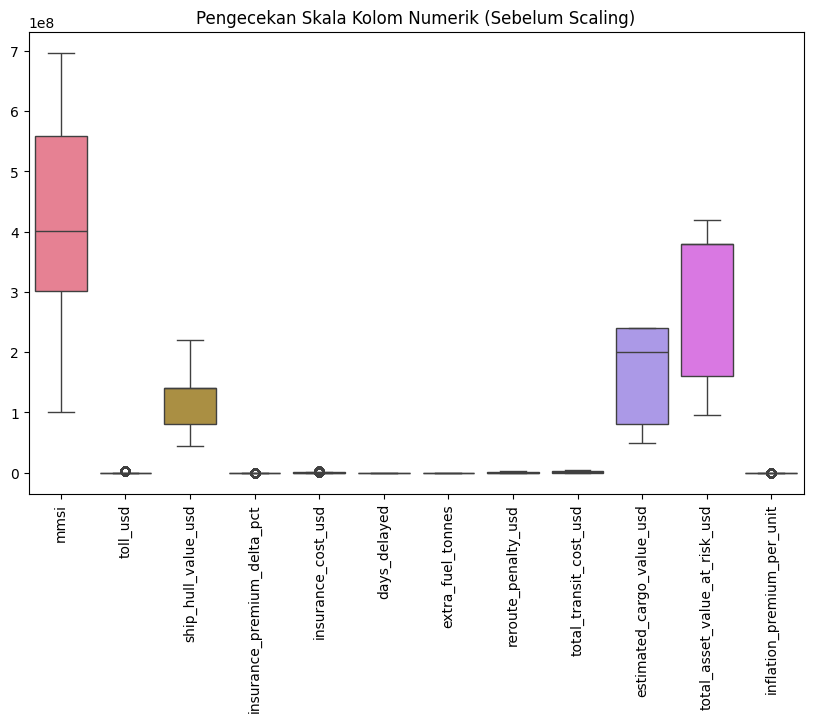

In [ ]:
kolom_cek = ['days_delayed', 'insurance_cost_usd', 'total_asset_value_at_risk_usd']

plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.title('Pengecekan Skala Kolom Numerik (Sebelum Scaling)')
plt.xticks(rotation=90)
plt.show()

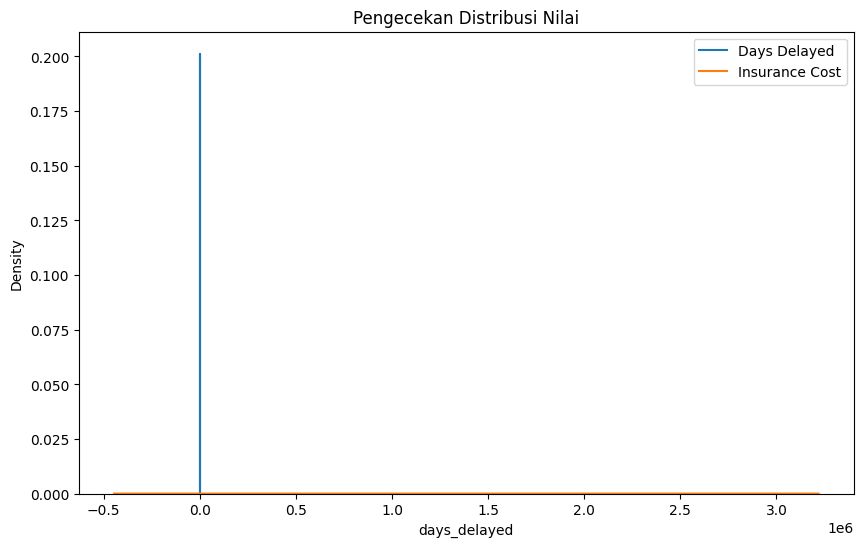

In [ ]:
plt.figure(figsize=(10, 6))

# Memplot masing-masing kolom dalam satu kanvas
sns.kdeplot(data=df['days_delayed'], label='Days Delayed')
sns.kdeplot(data=df['insurance_cost_usd'], label='Insurance Cost')

plt.title('Pengecekan Distribusi Nilai')
plt.legend()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

# Asumsikan 'df' adalah dataframe kamu yang sudah di-drop missing values-nya
# Kita pilih beberapa kolom numerik yang rentang angkanya jomplang
kolom_numerik = ['days_delayed', 'insurance_cost_usd', 'total_asset_value_at_risk_usd']

# 1. Panggil scalernya
scaler = StandardScaler()

# 2. Fit dan Transform data numerik tersebut
# Kita buat salinan dataframe agar data asli tidak hilang
df_scaled = df.copy()
df_scaled[kolom_numerik] = scaler.fit_transform(df[kolom_numerik])

# Lihat hasilnya
print(df_scaled[kolom_numerik].head())

   days_delayed  insurance_cost_usd  total_asset_value_at_risk_usd
0     -0.746215           -0.621547                      -1.024240
1     -0.746215           -0.579077                       0.713758
2     -0.746215           -0.579077                       0.713758
3     -0.746215            0.737494                      -1.024240
4     -0.746215           -0.579077                       0.713758


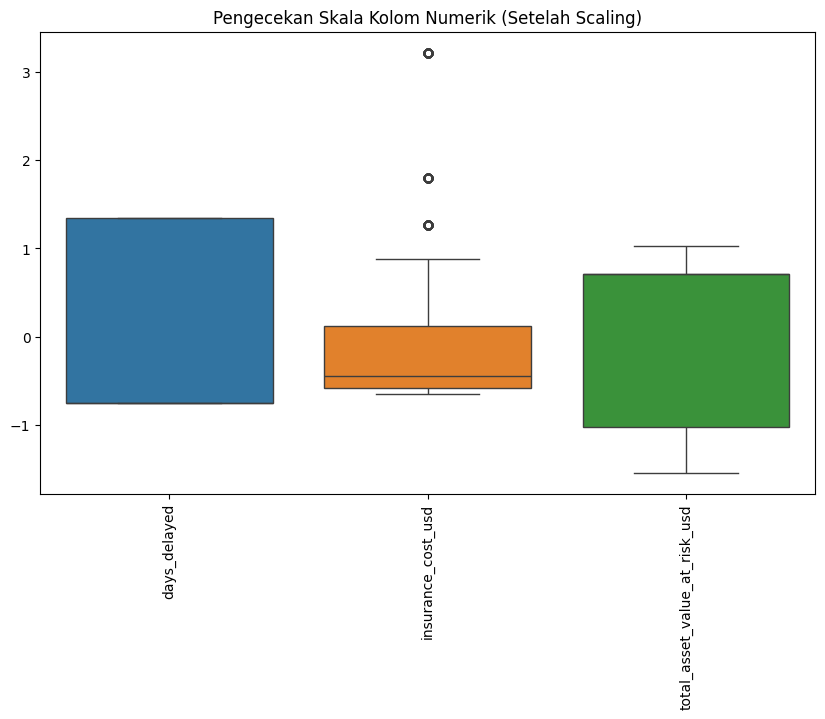

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_scaled[kolom_cek])
plt.title('Pengecekan Skala Kolom Numerik (Setelah Scaling)')
plt.xticks(rotation=90)
plt.show()

1. Sumbu Y Bukan Lagi "Hari" atau "Dolar"

Perhatikan angka di sumbu vertikal sebelah kiri (berkisar antara -1 hingga sekitar 3). Angka ini sekarang merepresentasikan Z-score (standar deviasi).

Angka 0.0 di tengah adalah nilai rata-rata (mean) dari masing-masing kolom.

Jika sebuah data berada di angka 1, itu berarti nilainya lebih tinggi 1 standar deviasi dari rata-rata. Jika minus, berarti di bawah rata-rata.

2. Skala Sudah Adil (Tujuan Utama Tercapai)

Lihat bagaimana ketiga kotak (box) tersebut sekarang terlihat berdampingan secara proporsional.
Jika kamu membuat visualisasi ini sebelum scaling, kolom total_asset_value_at_risk_usd (yang nilainya jutaan dolar) akan memakan seluruh layar, sementara days_delayed (yang mungkin hanya puluhan hari) akan terlihat seperti garis lurus yang mati di angka nol.
Sekarang, karena rentang nilainya sudah diseragamkan, algoritma K-Means tidak akan "dijajah" oleh kolom nilai aset. Perbedaan jumlah hari delay kini memiliki "bobot" matematis yang setara dengan perbedaan nilai asuransi.

3. Terdeteksinya Outlier (Anomali)

Perhatikan kolom yang berada di tengah (insurance_cost_usd). Kamu bisa melihat ada beberapa titik (lingkaran kecil) yang melayang jauh di atas kotak, bahkan ada satu yang melebihi angka 3.
Titik-titik ini adalah outlier. Visual ini memberi tahu kamu sebuah insight berharga: ada segelintir kasus kapal di dalam datamu yang dikenakan biaya asuransi ekstrem sangat mahal, jauh melampaui tarif normal yang dikenakan pada mayoritas kapal lainnya.

# Modelling

In [ ]:
from yellowbrick.cluster import KElbowVisualizer  # Mengimpor KElbowVisualizer untuk visualisasi metode Elbow

from sklearn.cluster import KMeans, DBSCAN  # Mengimpor algoritma KMeans dan DBSCAN untuk clustering
from sklearn.metrics import silhouette_score  # Mengimpor silhouette_score untuk mengevaluasi hasil clustering

In [ ]:
df_scaled

,date,vessel_name,mmsi,flag,trade_tier,transit_status,toll_usd,rerouted,commodity,destination,...,insurance_premium_delta_pct,insurance_cost_usd,days_delayed,extra_fuel_tonnes,reroute_penalty_usd,total_transit_cost_usd,estimated_cargo_value_usd,total_asset_value_at_risk_usd,continent,inflation_premium_per_unit
0,2026-03-01,MarchVessel_1,100000001,India,Privileged,Passed,0,No,Various,Global Port,...,0.05,-0.621547,-0.746215,0,0,40000,80000000,-1.024240,Asia,35.101053
1,2026-03-01,MarchVessel_2,100000002,Iran,Privileged,Passed,0,No,Crude Oil,Hidden,...,0.05,-0.579077,-0.746215,0,0,70000,240000000,0.713758,Asia,0.035000
2,2026-03-01,MarchVessel_3,100000003,Iran,Privileged,Passed,0,No,Crude Oil,Hidden,...,0.05,-0.579077,-0.746215,0,0,70000,240000000,0.713758,Asia,0.035000
3,2026-03-02,MarchVessel_4,100000004,Greece,Taxed,Passed,2000000,No,Various,Global Port,...,1.25,0.737494,-0.746215,0,0,3000000,80000000,-1.024240,Europe,35.101053
4,2026-03-02,MarchVessel_5,100000005,Iran,Privileged,Passed,0,No,Crude Oil,Hidden,...,0.05,-0.579077,-0.746215,0,0,70000,240000000,0.713758,Asia,0.035000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1885,2026-05-31,Iron Carrier 15,386403601,UK,Blocked,Rerouted,0,Yes (Cape of Good Hope),Bulk Carrier,Mumbai,...,0.15,-0.582617,1.340096,480,607200,674700,50000000,-1.537740,Europe,35.101053
1886,2026-05-31,Global Star 34,369408512,Iran,Privileged,Passed,0,No,Container Ship,Hidden/Private,...,0.05,-0.600312,-0.746215,0,0,55000,150000000,-0.234241,Asia,3.666667
1887,2026-05-31,Red Spirit 36,559556395,Liberia,Taxed,Passed,2000000,No,LNG Carrier,Houston,...,1.25,3.214912,-0.746215,0,0,4750000,200000000,1.029758,Africa,1.397059
1888,2026-05-31,Eastern Titan 10,238114122,Russia,Privileged,Passed,0,No,Container Ship,Hidden/Private,...,0.05,-0.600312,-0.746215,0,0,55000,150000000,-0.234241,Eurasia,3.666667


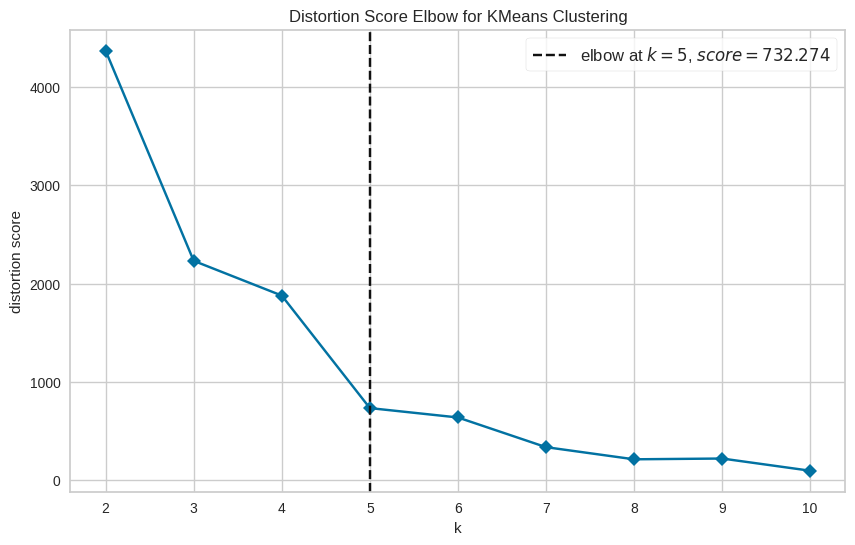

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
model = KMeans()

visualizer = KElbowVisualizer(model, k=(2,11), metric='distortion', timings=False)

plt.figure(figsize=(10, 6))
visualizer.fit(df_scaled[kolom_cek])
visualizer.show()

In [ ]:
# 1. Eksekusi K-Means dengan K=5 (sesuai rekomendasi grafik)
kmeans_final = KMeans(n_clusters=5, random_state=42)
kmeans_final.fit(df_scaled[kolom_numerik])

# 2. Tempelkan hasil cluster (0, 1, 2, 3, 4) ke dataframe aslimu
df['cluster_label'] = kmeans_final.labels_

# Cek 5 baris pertama untuk memastikan labelnya sudah masuk
print(df.head())

         date    vessel_name       mmsi    flag  trade_tier transit_status  \
0  2026-03-01  MarchVessel_1  100000001   India  Privileged         Passed   
1  2026-03-01  MarchVessel_2  100000002    Iran  Privileged         Passed   
2  2026-03-01  MarchVessel_3  100000003    Iran  Privileged         Passed   
3  2026-03-02  MarchVessel_4  100000004  Greece       Taxed         Passed   
4  2026-03-02  MarchVessel_5  100000005    Iran  Privileged         Passed   

   toll_usd rerouted  commodity  destination  ... insurance_cost_usd  \
0         0       No    Various  Global Port  ...              40000   
1         0       No  Crude Oil       Hidden  ...              70000   
2         0       No  Crude Oil       Hidden  ...              70000   
3   2000000       No    Various  Global Port  ...            1000000   
4         0       No  Crude Oil       Hidden  ...              70000   

   days_delayed  extra_fuel_tonnes  reroute_penalty_usd  \
0             0                  0     

In [ ]:
profil_risiko = df.groupby('cluster_label')[kolom_numerik].mean()

# Tampilkan hasilnya sebagai tabel
display(profil_risiko)

,days_delayed,insurance_cost_usd,total_asset_value_at_risk_usd
cluster_label,,,
0,12.0,1.142544e+05,1.741228e+08
1,0.0,1.703072e+05,3.651195e+08
2,0.0,2.290107e+06,4.016043e+08
3,0.0,5.593141e+05,1.468254e+08
4,12.0,2.743114e+05,4.014371e+08


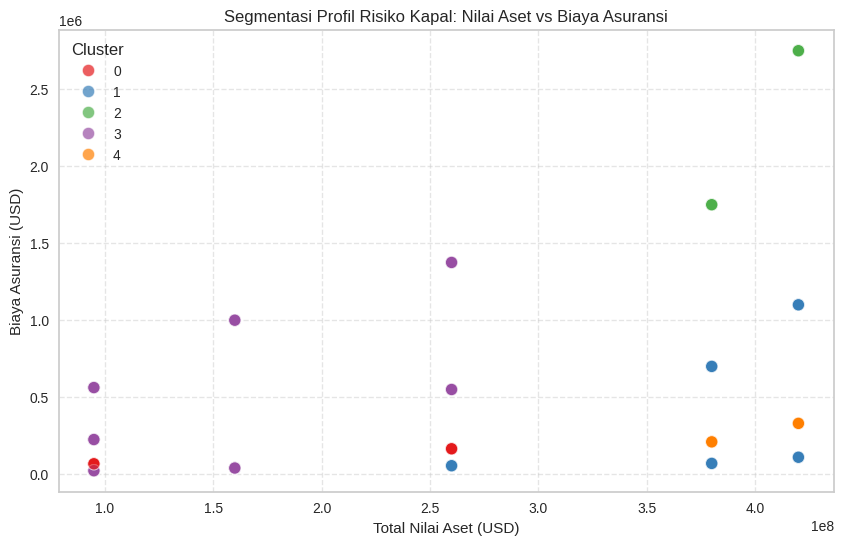

In [ ]:
plt.figure(figsize=(10, 6))

# Membuat scatter plot dari data asli (bukan yang di-scale) agar angkanya nyata
sns.scatterplot(
    data=df,
    x='total_asset_value_at_risk_usd',
    y='insurance_cost_usd',
    hue='cluster_label', # Mewarnai titik berdasarkan label cluster
    palette='Set1',      # Pilihan palet warna yang kontras
    s=80,                # Ukuran titik
    alpha=0.7            # Transparansi agar titik yang menumpuk tetap terlihat
)

plt.title('Segmentasi Profil Risiko Kapal: Nilai Aset vs Biaya Asuransi')
plt.xlabel('Total Nilai Aset (USD)')
plt.ylabel('Biaya Asuransi (USD)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Temuan: Perhatikan Cluster 2 (Titik Hijau). Titik-titik ini berada di ujung paling kanan (membawa Total Nilai Aset terbesar, menembus angka 350 hingga 400+ juta USD) dan posisinya menjulang paling tinggi di sumbu Y (membayar Biaya Asuransi paling mahal, di atas 1,5 hingga 2,5 juta USD).

Kesimpulan Bisnis: Cluster 2 adalah kelompok "Kapal High-Value / Risiko Finansial Tinggi". Pihak asuransi membebankan biaya premi yang sangat mahal (ekstrem) kepada armada ini semata-mata karena nilai muatan yang mereka bawa sangat raksasa. Jika terjadi kecelakaan pada satu kapal saja di cluster ini, perusahaan asuransi bisa rugi besar.

/tmp/ipykernel_2074/4241765622.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


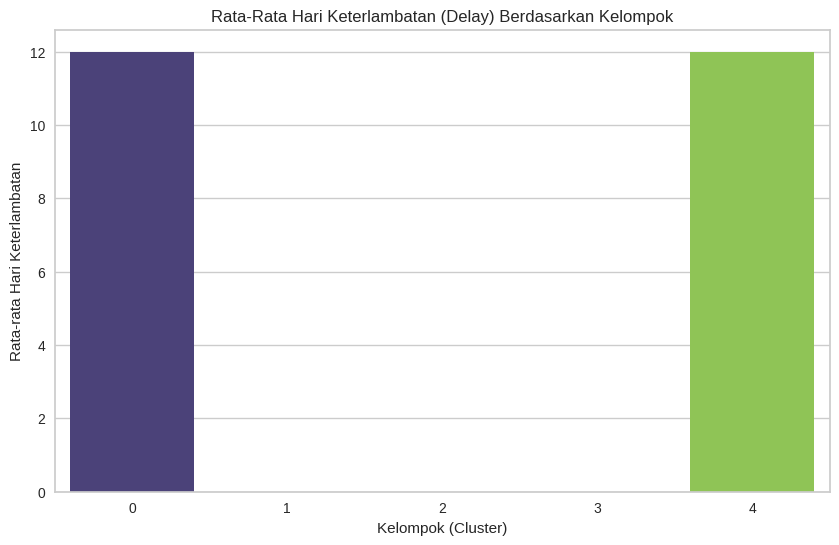

In [ ]:
plt.figure(figsize=(10, 6))

# Memvisualisasikan rata-rata hari keterlambatan per cluster
sns.barplot(
    data=df,
    x='cluster_label',
    y='days_delayed',
    palette='viridis',
    errorbar=None # Menghilangkan garis error agar grafik lebih bersih
)

plt.title('Rata-Rata Hari Keterlambatan (Delay) Berdasarkan Kelompok')
plt.xlabel('Kelompok (Cluster)')
plt.ylabel('Rata-rata Hari Keterlambatan')
plt.show()

Temuan: Perhatikan bahwa keterlambatan parah tidak dialami oleh armada elit di Cluster 2. Keterlambatan rata-rata 12 hari (delay) justru didominasi secara eksklusif oleh Cluster 0 (Ungu Gelap) dan Cluster 4 (Hijau Muda).

Kesimpulan Bisnis: Ini adalah kelompok "Kapal Risiko Operasional Tinggi". Menariknya, jika kita silangkan dengan grafik pertama, kapal di Cluster 0 memiliki nilai aset yang rendah, sedangkan Cluster 4 memiliki aset yang tinggi. Namun, keduanya sama-sama memiliki performa logistik yang buruk (langganan delay parah).

# Subjek: Hasil Segmentasi Profil Risiko Armada Kapal (K-Means Clustering)

Selamat siang, berdasarkan pemrosesan ribuan data historis pelayaran kita, algoritma clustering berhasil membagi profil risiko kapal menjadi beberapa temuan krusial:

Fokus Risiko Finansial (Cluster 2): Algoritma mendeteksi kelompok kapal prioritas (Cluster 2) yang membawa muatan bernilai fantastis (hingga melampaui 400 juta USD per pelayaran). Kapal-kapal kelas elit ini menyedot biaya premi asuransi tertinggi. Pengawasan rute dan keamanan pada kelompok ini harus menjadi prioritas absolut untuk mencegah klaim bernilai triliunan Rupiah.

Fokus Risiko Operasional Logistik (Cluster 0 dan Cluster 4): Kita mendeteksi adanya anomali performa pada dua kelompok armada ini. Kapal-kapal yang masuk ke dalam Cluster 0 dan 4 tercatat secara konsisten mengalami keterlambatan pelayaran (delay) rata-rata hingga 12 hari.

Rekomendasi Tindakan: Perusahaan perlu mengevaluasi vendor ekspedisi, rute, atau kapten kapal yang berada di dalam daftar Cluster 0 dan 4 untuk menginvestigasi penyebab lambatnya waktu tempuh yang dapat merusak Service Level Agreement (SLA) perusahaan.